<a href="https://colab.research.google.com/github/TEMADANGSERAPHIN/PROJET-DETECTION-DE-FRAUD-BANCAIRE/blob/main/Precessus_creation_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALYSE DE DÉTECTION DE FRAUDE À LA CARTE BANCAIRE

Développez un modèle d'apprentissage automatique (machine learning) pour identifier les transactions frauduleuses par carte bancaire.

**Préparation des données :** Prétraitez et normalisez les données de transaction, gérez les problèmes de déséquilibre des classes et divisez l'ensemble de données en sous-ensembles d'entraînement et de test.

In [ ]:
# charger les fichier depuis google drive?
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Les bibliotheques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Charger le jeux de données

In [ ]:
FRMQR = pd.read_csv('/content/drive/MyDrive/Codesoft/creditcard.csv')
FRMQR.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
FRMQR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Configuration esthétique pour LinkedIn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# --- 1. ANALYSE DESCRIPTIVE : LE MIROIR DE LA RÉALITÉ ---
print("--- Analyse du déséquilibre ---")
counts = FRMQR['Class'].value_counts()
percent_fraud = (counts[1] / len(FRMQR)) * 100
print("Le pourcentage de Fraude est :", percent_fraud)

--- Analyse du déséquilibre ---
Le pourcentage de Fraude est : 0.1727485630620034


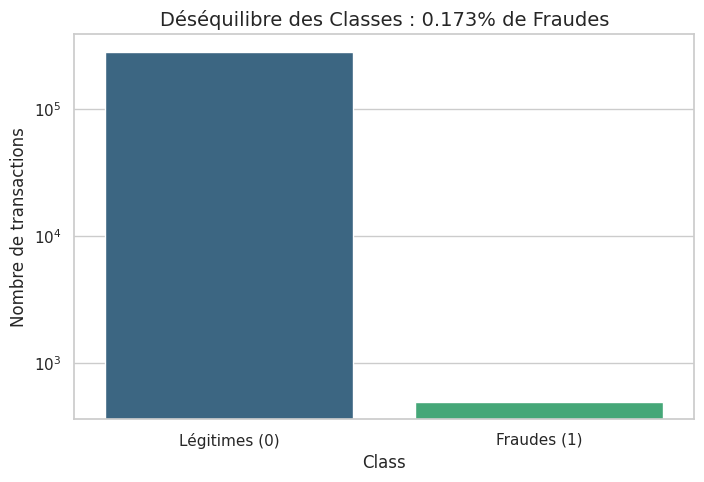

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title(f'Déséquilibre des Classes : {percent_fraud:.3f}% de Fraudes', fontsize=14)
plt.ylabel('Nombre de transactions')
plt.xticks([0, 1], ['Légitimes (0)', 'Fraudes (1)'])
plt.yscale('log') # Échelle logarithmique pour voir la barre des fraudes !
plt.show()

In [ ]:
# 2. Application de la "formule magique"
# // 3600 : division entière pour obtenir le nombre d'heures
# % 24   : modulo pour rester dans un cycle de 24h (0 à 23)
FRMQR['Hour'] = (FRMQR['Time'] // 3600) % 24

# 3. Vérification des résultats
print("Aperçu de la conversion (Time vs Hour) :")
print(FRMQR[['Time', 'Hour']].head(10))

Aperçu de la conversion (Time vs Hour) :
   Time  Hour
0   0.0   0.0
1   0.0   0.0
2   1.0   0.0
3   1.0   0.0
4   2.0   0.0
5   2.0   0.0
6   4.0   0.0
7   7.0   0.0
8   7.0   0.0
9   9.0   0.0


In [ ]:
print("\nHeure des transactions :")
print(FRMQR.groupby('Class')['Hour'].value_counts())


Heure des transactions :
Class  Hour
0      21.0    17687
       18.0    17006
       11.0    16803
       20.0    16738
       10.0    16590
       14.0    16547
       15.0    16435
       16.0    16431
       17.0    16137
       9.0     15822
       19.0    15630
       22.0    15432
       12.0    15403
       13.0    15348
       23.0    10917
       8.0     10267
       0.0      7689
       7.0      7220
       1.0      4210
       6.0      4092
       3.0      3475
       2.0      3271
       5.0      2979
       4.0      2186
1      2.0        57
       11.0       53
       18.0       33
       17.0       29
       15.0       26
       4.0        23
       7.0        23
       14.0       23
       16.0       22
       23.0       21
       19.0       19
       20.0       18
       3.0        17
       12.0       17
       13.0       17
       9.0        16
       21.0       16
       5.0        11
       1.0        10
       6.0         9
       8.0         9
       22.0      

In [ ]:
# 4. Petit bonus : Analyse rapide pour votre post LinkedIn
# Comparons la moyenne de l'heure pour les transactions normales vs fraudes
print("\nHeure moyenne des transactions :")
print(FRMQR.groupby('Class')['Hour'].mean())


Heure moyenne des transactions :
Class
0    14.050623
1    11.646341
Name: Hour, dtype: float64


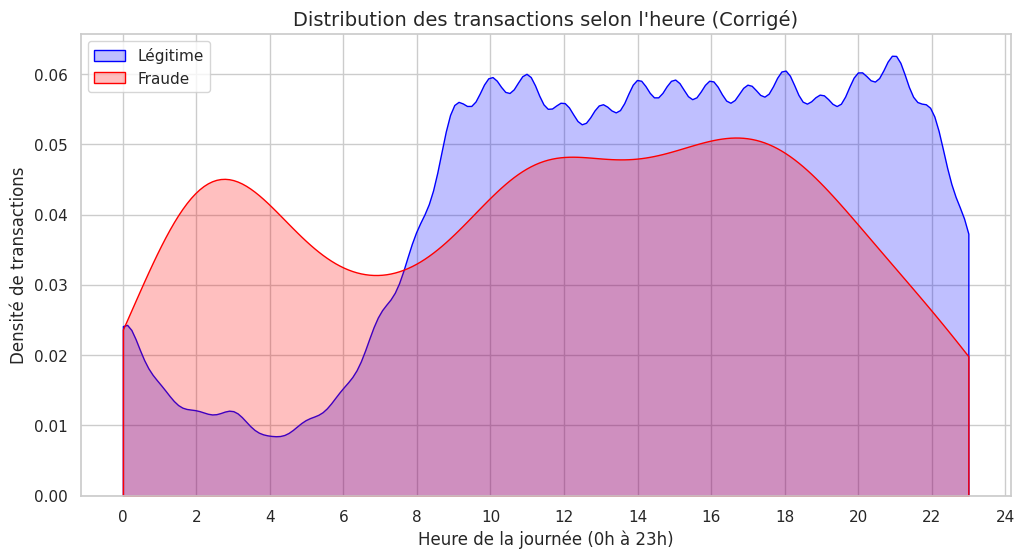

In [ ]:
plt.figure(figsize=(12, 6))

# On ajoute clip=(0, 23) pour couper les débordements mathématiques
sns.kdeplot(FRMQR[FRMQR['Class'] == 0]['Hour'], label='Légitime', fill=True, color='blue', clip=(0, 23))
sns.kdeplot(FRMQR[FRMQR['Class'] == 1]['Hour'], label='Fraude', fill=True, color='red', clip=(0, 23))

plt.title('Distribution des transactions selon l\'heure (Corrigé)', fontsize=14)
plt.xlabel('Heure de la journée (0h à 23h)')
plt.ylabel('Densité de transactions')
plt.xticks(range(0, 25, 2)) # Affiche les heures de 2 en 2 pour plus de clarté
plt.legend()
plt.show()

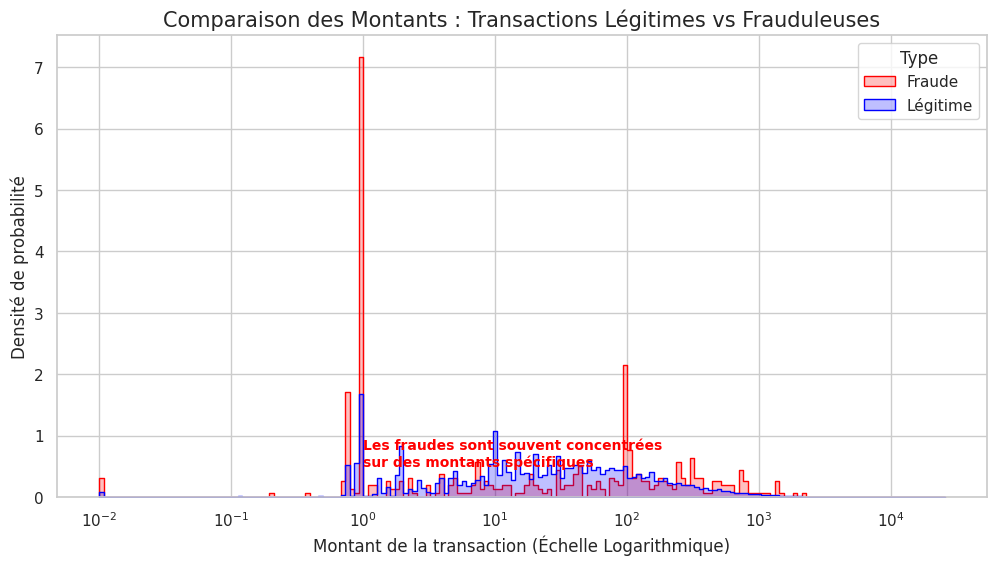

In [ ]:
# On s'assure que le style est professionnel pour LinkedIn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Création du graphique de densité pour comparer les montants
# On utilise log_scale=True sur l'axe X car les montants vont de 0 à 25 000+
sns.histplot(data=FRMQR, x='Amount', hue='Class', element="step",
             stat="density", common_norm=False, palette=['blue', 'red'],
             log_scale=(True, False))

plt.title('Comparaison des Montants : Transactions Légitimes vs Frauduleuses', fontsize=15)
plt.xlabel('Montant de la transaction (Échelle Logarithmique)')
plt.ylabel('Densité de probabilité')
plt.legend(title='Type', labels=['Fraude', 'Légitime'])

# Ajout d'une note explicative sur le graphique
plt.text(1, 0.5, "Les fraudes sont souvent concentrées\nsur des montants spécifiques",
         fontsize=10, color='red', fontweight='bold')

plt.show()

Le Pic Critique (autour de 10°=1) : On observe une densité de probabilité massive pour la fraude aux alentours de 1 unitée monétaire.

Interprétation : C'est la technique classique du "Card Testing". Le fraudeur tente un micro-paiement pour vérifier si la carte est active avant de tenter un plus gros coup.

Les fraudeurs effectuent souvent des "micro-transactions tests" pour vérifier si une carte fonctionne avant de tenter des achats plus importants. Un petit montant inhabituel est souvent le premier signe d'une fraude imminente.

In [ ]:
# --- 3. ANALYSE DES MONTANTS (Transactions test vs Fraude réelle) ---
print("--- Statistiques des Montants ---")
print(FRMQR.groupby('Class')['Amount'].describe())

--- Statistiques des Montants ---
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


<Axes: xlabel='Class', ylabel='Amount'>

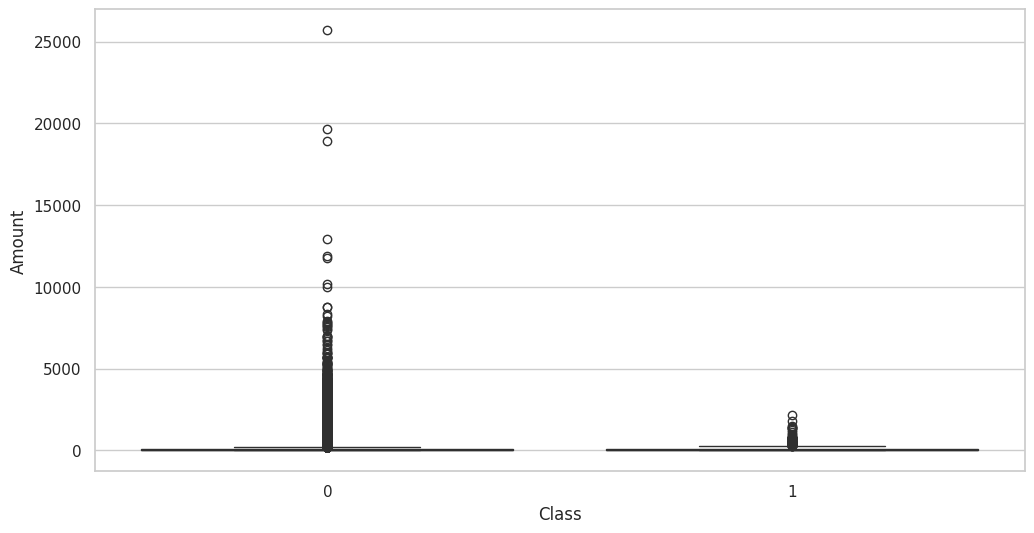

In [ ]:
sns.boxplot(x='Class', y='Amount', data=FRMQR, palette='magma', hue='Class', legend=False)

/tmp/ipython-input-3440461664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=FRMQR, palette='magma')


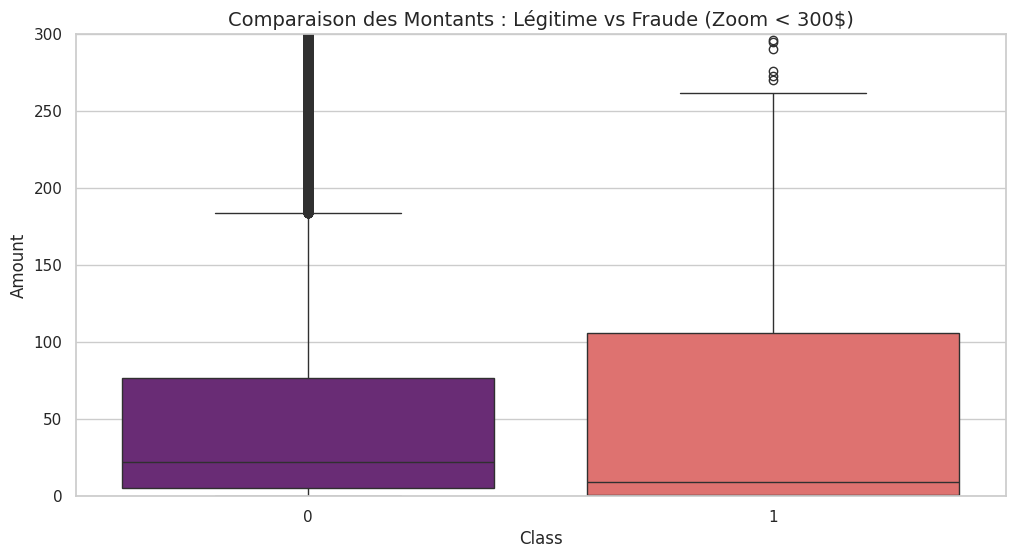

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='Amount', data=FRMQR, palette='magma')
plt.ylim(0, 300) # On limite pour mieux voir la boîte (exclusion des outliers extrêmes)
plt.title('Comparaison des Montants : Légitime vs Fraude (Zoom < 300$)', fontsize=14)
plt.show()

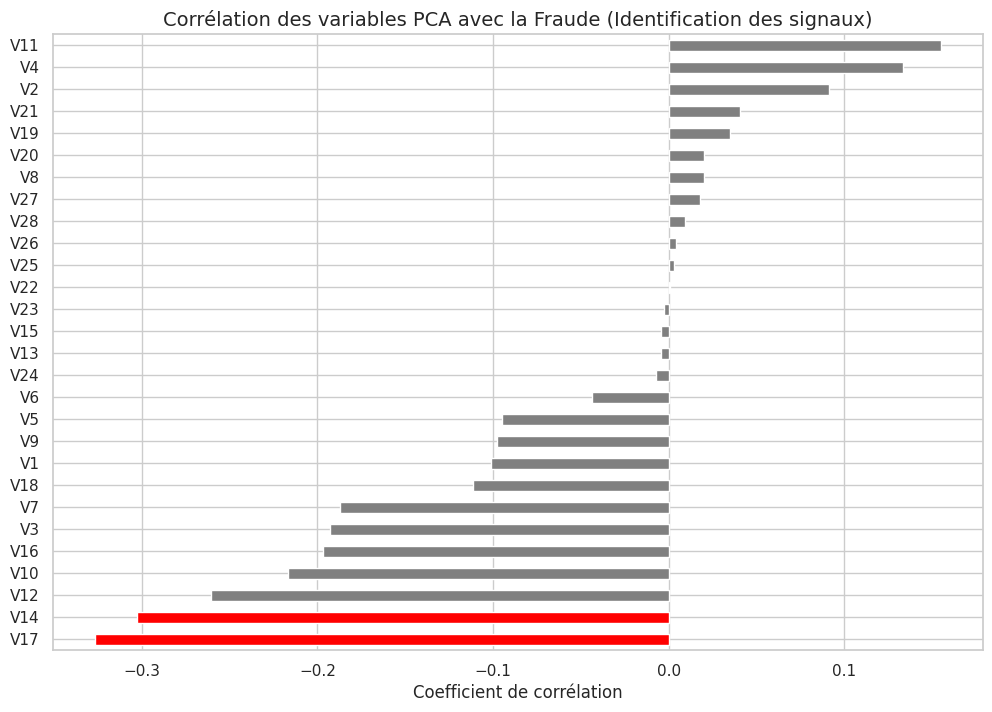

In [ ]:
# --- 4. CORRÉLATION AVEC LES VARIABLES PCA (V1 à V28) ---
# On regarde quelles variables V sont les plus liées à la classe 'Class'
correlations = FRM.corr()['Class'].drop(['Class', 'Time', 'Amount', 'Hour']).sort_values()

plt.figure(figsize=(12, 8))
colors = ['red' if x < -0.3 or x > 0.3 else 'grey' for x in correlations.values]
correlations.plot(kind='barh', color=colors)
plt.title('Corrélation des variables PCA avec la Fraude (Identification des signaux)', fontsize=14)
plt.xlabel('Coefficient de corrélation')
plt.show()

# **Ce graphique montre quelles variables influencent le plus la détection de la fraude.**

**Les barres rouges (V17, V14)** :

Ce sont les variables qui ont la plus forte
corrélation négative (proche de -0.3). Cela signifie que lorsque la valeur de V17 ou V14 baisse drastiquement, la probabilité de fraude augmente fortement.

**La hiérarchie des signaux** :

Vous voyez que V17, V14, V12 et V10 sont vos "capteurs" les plus sensibles. À l'inverse, des variables comme V25 ou V26 n'ont presque aucun impact (barres très courtes).